# 用 NumPy 從零實作 Transformer 完整反向傳播訓練

本筆記本在 NumPy 版的基礎上，**手動推導並實作每一層的解析梯度**，取代數值微分，實現真正的 Backpropagation。

## 新增功能（相比上一版）

| 功能 | 上一版（NumPy）| **本版（Backprop）** |
|---|---|---|
| 梯度計算 | 數值微分（O(P) 次前向）| ✅ 解析反向傳播（O(1) 次）|
| 注意力頭數 | 單頭 | ✅ 多頭 Multi-Head Attention |
| 優化器 | SGD | ✅ Adam（動量 + 自適應學習率）|
| 訓練監控 | 損失數字 | ✅ 損失曲線 + 梯度範數 + 注意力圖 |
| 模型層數 | 1 層 | ✅ 可設定 N 層 |
| 梯度驗證 | 無 | ✅ 數值 vs 解析梯度對比 |

## 反向傳播公式速查

| 層 | Forward | Backward（關鍵梯度）|
|---|---|---|
| Embedding | `X = W[ids]` | `dW` 用 `np.add.at` scatter-add |
| LayerNorm | `y=(x-μ)/σ` | 推導見 Cell 4 |
| ReLU | `max(0,x)` | `dy * (x>0)` |
| Linear | `y=xW+b` | `dW=x.T@dy, db=dy.sum(0), dx=dy@W.T` |
| Softmax+CE | `loss=-log(p_t)` | `dlogits=(p-onehot)/T` |
| Attention | `A=softmax(QK^T/√d)V` | 見 Cell 7 |
| Residual | `y=x+f(x)` | `dx = dy + df` |

## 1. 超參數與詞彙表

In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── 亂數種子 ──────────────────────────────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

# ── 詞彙表 ────────────────────────────────────────────────────────────────────
VOCAB = list("abcdefghijklmnopqrstuvwxyz .,!?\n")
V = len(VOCAB)
char2id = {c: i for i, c in enumerate(VOCAB)}
id2char = {i: c for c, i in char2id.items()}

# ── 模型超參數 ────────────────────────────────────────────────────────────────
D = 64  # d_model（隱藏層維度）
D_FF = 128  # Feed Forward 中間層維度
N_HEADS = 4  # 多頭注意力頭數（D 必須能被 N_HEADS 整除）
N_LAYERS = 2  # Transformer Block 層數
SEQ_LEN = 32  # 最大序列長度

# ── 訓練超參數 ────────────────────────────────────────────────────────────────
LR = 3e-3  # Adam 學習率
N_STEPS = 200  # 訓練步數
CLIP = 1.0  # Gradient Clipping 上限

assert D % N_HEADS == 0, f"D={D} 必須能被 N_HEADS={N_HEADS} 整除"
print(f"詞彙表大小: {V}")
print(f"模型維度 D={D}, FFN={D_FF}, Heads={N_HEADS}, Layers={N_LAYERS}")
print(f"每頭維度 dk = {D // N_HEADS}")

詞彙表大小: 32
模型維度 D=64, FFN=128, Heads=4, Layers=2
每頭維度 dk = 16


## 2. 基礎工具函數（Forward）

In [17]:
def randn(shape, scale=0.02):
    """He-style 隨機初始化"""
    return rng.standard_normal(shape) * scale


def softmax(x, axis=-1):
    """數值穩定 softmax（向量化）"""
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)


def positional_encoding(T, D):
    """sin/cos PE，shape (T, D)，廣播向量化"""
    pos = np.arange(T)[:, None]
    i = np.arange(0, D, 2)[None, :]
    ang = pos / (10000 ** (i / D))
    pe = np.zeros((T, D))
    pe[:, 0::2] = np.sin(ang)
    pe[:, 1::2] = np.cos(ang[:, : D // 2])
    return pe


# 快速測試
pe = positional_encoding(8, D)
print(f"PE shape: {pe.shape}")
print(f"softmax([1,2,3]): {softmax(np.array([1.,2.,3.])).round(3)}")

PE shape: (8, 64)
softmax([1,2,3]): [0.09  0.245 0.665]


## 3. Layer Normalization（含完整反向傳播推導）

### Forward
$$\hat{x} = \frac{x - \mu}{\sigma}, \quad \mu = \frac{1}{D}\sum x_i, \quad \sigma = \sqrt{\text{Var}(x)+\epsilon}$$

### Backward（推導）
設上游梯度為 $\partial L/\partial \hat{x}$，對 $x$ 的梯度為：

$$\frac{\partial L}{\partial x} = \frac{1}{D\sigma}\left[D \cdot \frac{\partial L}{\partial \hat{x}} - \sum_j \frac{\partial L}{\partial \hat{x}_j} - \hat{x} \cdot \sum_j \frac{\partial L}{\partial \hat{x}_j}\hat{x}_j\right]$$

直覺：梯度需要去除「均值方向」（不改變 mean）和「scale 方向」（不改變 std）的分量。

In [18]:
def layer_norm_fwd(x, eps=1e-6):
    """
    Layer Norm forward pass
    x:  ndarray (..., D)
    回傳: y（正規化後）, mean, std（供 backward 使用）
    """
    mean = x.mean(axis=-1, keepdims=True)  # (..., 1)
    var = x.var(axis=-1, keepdims=True)  # (..., 1)
    std = np.sqrt(var + eps)  # (..., 1)
    y = (x - mean) / std
    return y, mean, std


def layer_norm_bwd(dy, x, std):
    """
    Layer Norm backward pass
    dy:  上游梯度，shape (..., D)
    x:   原始輸入（用於計算 x_hat）
    std: forward 時記錄的標準差
    回傳: dx，shape (..., D)
    """
    D = x.shape[-1]
    mean = x.mean(axis=-1, keepdims=True)
    xhat = (x - mean) / std  # 標準化後的值
    # 三項：全梯度、去均值、去scale
    dx = (
        (1.0 / D)
        / std
        * (
            D * dy
            - dy.sum(axis=-1, keepdims=True)
            - xhat * (dy * xhat).sum(axis=-1, keepdims=True)
        )
    )
    return dx


# ── 梯度驗證 ─────────────────────────────────────────────────────────────────
def grad_check(fwd_fn, bwd_fn, x, dy, eps=1e-5):
    """有限差分 vs 解析梯度，回傳最大誤差"""
    y, *cache = fwd_fn(x)
    dx_ana = bwd_fn(dy, x, *cache[1:])  # 跳過 mean，只用 std
    dx_num = np.zeros_like(x)
    for idx in np.ndindex(x.shape):
        orig = x[idx]
        x[idx] = orig + eps
        yp, *_ = fwd_fn(x)
        lp = (yp * dy).sum()
        x[idx] = orig - eps
        ym, *_ = fwd_fn(x)
        lm = (ym * dy).sum()
        x[idx] = orig
        dx_num[idx] = (lp - lm) / (2 * eps)
    return float(np.max(np.abs(dx_num - dx_ana)))


x_test = rng.standard_normal((4, 16))
dy_test = rng.standard_normal((4, 16))
err = grad_check(
    layer_norm_fwd, lambda dy, x, std: layer_norm_bwd(dy, x, std), x_test, dy_test
)
print(f"LayerNorm 梯度誤差: {err:.2e}  {'✓' if err < 1e-7 else '✗'}")

LayerNorm 梯度誤差: 1.75e-10  ✓


## 4. Multi-Head Self-Attention（含完整反向傳播）

### 多頭拆分
- 將 $D$ 維向量拆成 $H$ 個頭，每頭維度 $d_k = D/H$
- 各頭獨立計算注意力，最後 concat 再投影

### Softmax 反向傳播（Jacobian 化簡）
$$\frac{\partial L}{\partial s_{ij}} = p_{ij}\left(\frac{\partial L}{\partial p_{ij}} - \sum_k p_{ik}\frac{\partial L}{\partial p_{ik}}\right)$$

向量化版：`d_scores = attn * (d_attn - (attn * d_attn).sum(axis=-1, keepdims=True))`

In [19]:
class MultiHeadAttention:
    """
    Multi-Head Causal Self-Attention with full backward pass.

    Forward shapes（以 H=4, T=seq_len, D=64, dk=16 為例）：
      X       : (T, D)
      Q,K,V   : (T, D)  → split → (H, T, dk)
      scores  : (H, T, T)
      attn    : (H, T, T)  softmax
      context : (T, D)  merge heads
      output  : (T, D)  @ Wo
    """

    def __init__(self, d_model, n_heads):
        self.D = d_model
        self.H = n_heads
        self.dk = d_model // n_heads
        # 參數矩陣（Xavier-style 初始化）
        s = 1.0 / math.sqrt(d_model)
        self.Wq = rng.standard_normal((d_model, d_model)) * s
        self.Wk = rng.standard_normal((d_model, d_model)) * s
        self.Wv = rng.standard_normal((d_model, d_model)) * s
        self.Wo = rng.standard_normal((d_model, d_model)) * s
        # Adam 狀態（每個參數矩陣一組 m, v）
        self._init_adam()

    def _init_adam(self):
        self._adam = {}
        for name in ["Wq", "Wk", "Wv", "Wo"]:
            W = getattr(self, name)
            self._adam[name] = dict(m=np.zeros_like(W), v=np.zeros_like(W))

    # ── Helper：多頭拆分 / 合併 ──────────────────────────────────────────────
    def _split(self, X):  # (T, D) → (H, T, dk)
        T = X.shape[0]
        return X.reshape(T, self.H, self.dk).transpose(1, 0, 2)

    def _merge(self, X):  # (H, T, dk) → (T, D)
        T = X.shape[1]
        return X.transpose(1, 0, 2).reshape(T, self.D)

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, X):
        T = X.shape[0]
        dk = math.sqrt(self.dk)

        Q = X @ self.Wq  # (T, D)
        K = X @ self.Wk
        V = X @ self.Wv

        Qh = self._split(Q)  # (H, T, dk)
        Kh = self._split(K)
        Vh = self._split(V)

        # Scaled Dot-Product Attention
        scores = Qh @ Kh.transpose(0, 2, 1) / dk  # (H, T, T)
        # Causal mask（上三角填 -inf，阻止看未來）
        causal = np.triu(np.full((T, T), -1e9), k=1)
        scores = scores + causal

        attn = softmax(scores, axis=-1)  # (H, T, T)
        context = self._merge(attn @ Vh)  # (T, D)
        out = context @ self.Wo  # (T, D)

        # 儲存 cache（backward 需要）
        self._cache = (X, Q, K, V, Qh, Kh, Vh, attn, context)
        return out

    # ── Backward ─────────────────────────────────────────────────────────────
    def backward(self, dout):
        X, Q, K, V, Qh, Kh, Vh, attn, context = self._cache
        dk = math.sqrt(self.dk)

        # 1. 輸出投影：out = context @ Wo
        self._grads = {}
        self._grads["Wo"] = context.T @ dout  # (D, D)
        d_context = dout @ self.Wo.T  # (T, D)

        # 2. 合併頭 → (H, T, dk)
        d_ctx_h = self._split(d_context)  # (H, T, dk)

        # 3. context = attn @ Vh
        d_attn = d_ctx_h @ Vh.transpose(0, 2, 1)  # (H, T, T)  dL/d_attn
        dVh = attn.transpose(0, 2, 1) @ d_ctx_h  # (H, T, dk)

        # 4. Softmax 反向（Jacobian 化簡公式）
        #    d_scores[i,j] = attn[i,j] * (d_attn[i,j] - Σ_k attn[i,k]*d_attn[i,k])
        s = attn * d_attn
        d_scores = (s - attn * s.sum(axis=-1, keepdims=True)) / dk  # (H,T,T)

        # 5. scores = Qh @ Kh.T → dQh, dKh
        dQh = d_scores @ Kh  # (H, T, dk)
        dKh = d_scores.transpose(0, 2, 1) @ Qh  # (H, T, dk)

        # 6. 合併 heads 得到 dQ, dK, dV (T, D)
        dQ = self._merge(dQh)
        dK = self._merge(dKh)
        dV = self._merge(dVh)

        # 7. Q=X@Wq 等 → dWq, dWk, dWv, dX
        self._grads["Wq"] = X.T @ dQ  # (D, D)
        self._grads["Wk"] = X.T @ dK
        self._grads["Wv"] = X.T @ dV

        dX = dQ @ self.Wq.T + dK @ self.Wk.T + dV @ self.Wv.T  # (T, D)
        return dX

    # ── Adam 更新 ─────────────────────────────────────────────────────────────
    def adam_step(self, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):
        for name in ["Wq", "Wk", "Wv", "Wo"]:
            g = self._grads[name]
            st = self._adam[name]
            st["m"] = beta1 * st["m"] + (1 - beta1) * g
            st["v"] = beta2 * st["v"] + (1 - beta2) * g**2
            m_hat = st["m"] / (1 - beta1**t)
            v_hat = st["v"] / (1 - beta2**t)
            getattr(self, name)[:] -= lr * m_hat / (np.sqrt(v_hat) + eps)


print("MultiHeadAttention 定義完成 ✓")

# ── 梯度驗證（dWq）─────────────────────────────────────────────────────────
T_test, D_test, H_test = 5, 8, 2
rng2 = np.random.default_rng(1)
attn_test = MultiHeadAttention.__new__(MultiHeadAttention)
attn_test.D = D_test
attn_test.H = H_test
attn_test.dk = D_test // H_test
for attr in ["Wq", "Wk", "Wv", "Wo"]:
    setattr(attn_test, attr, rng2.standard_normal((D_test, D_test)) * 0.1)
attn_test._split = MultiHeadAttention._split.__get__(attn_test)
attn_test._merge = MultiHeadAttention._merge.__get__(attn_test)
attn_test.forward = MultiHeadAttention.forward.__get__(attn_test)
attn_test.backward = MultiHeadAttention.backward.__get__(attn_test)

X_t = rng2.standard_normal((T_test, D_test)) * 0.1
dy_t = rng2.standard_normal((T_test, D_test)) * 0.1
_ = attn_test.forward(X_t)
_ = attn_test.backward(dy_t)
dWq_ana = attn_test._grads["Wq"].copy()

eps_fd = 1e-5
dWq_num = np.zeros_like(attn_test.Wq)
for i in range(D_test):
    for j in range(D_test):
        orig = attn_test.Wq[i, j]
        attn_test.Wq[i, j] = orig + eps_fd
        yp = attn_test.forward(X_t)
        attn_test.Wq[i, j] = orig - eps_fd
        ym = attn_test.forward(X_t)
        attn_test.Wq[i, j] = orig
        dWq_num[i, j] = ((yp - ym) * dy_t).sum() / (2 * eps_fd)

err_attn = float(np.max(np.abs(dWq_num - dWq_ana)))
print(f"MHA dWq 梯度誤差: {err_attn:.2e}  {'✓' if err_attn < 1e-5 else '✗'}")

MultiHeadAttention 定義完成 ✓
MHA dWq 梯度誤差: 4.46e-14  ✓


## 5. Feed Forward Network（含反向傳播）

$$\text{FFN}(X) = \text{ReLU}(XW_1 + b_1)W_2 + b_2$$

### Backward
- `d_out → dW2 = h.T @ d_out`，`db2 = d_out.sum(0)`
- `d_h = d_out @ W2.T`
- ReLU gate：`d_h_pre = d_h * (h_pre > 0)`
- `dW1 = X.T @ d_h_pre`，`db1 = d_h_pre.sum(0)`
- `dX = d_h_pre @ W1.T`

In [20]:
class FeedForward:
    """
    Position-wise FFN with backward pass and Adam optimizer.
    """

    def __init__(self, d_model, d_ff):
        s = 1.0 / math.sqrt(d_model)
        self.W1 = rng.standard_normal((d_model, d_ff)) * s
        self.b1 = np.zeros(d_ff)
        self.W2 = rng.standard_normal((d_ff, d_model)) * s
        self.b2 = np.zeros(d_model)
        self._init_adam()

    def _init_adam(self):
        self._adam = {}
        for name, p in [
            ("W1", self.W1),
            ("b1", self.b1),
            ("W2", self.W2),
            ("b2", self.b2),
        ]:
            self._adam[name] = dict(m=np.zeros_like(p), v=np.zeros_like(p))

    def forward(self, X):
        """X: (T, D) → (T, D)"""
        self._X = X
        self._h_pre = X @ self.W1 + self.b1  # (T, D_FF)
        self._h = np.maximum(0.0, self._h_pre)  # ReLU
        return self._h @ self.W2 + self.b2  # (T, D)

    def backward(self, dout):
        """dout: (T, D) → dX: (T, D)，同時儲存參數梯度"""
        self._grads = {}
        self._grads["W2"] = self._h.T @ dout  # (D_FF, D)
        self._grads["b2"] = dout.sum(axis=0)  # (D,)
        dh = dout @ self.W2.T  # (T, D_FF)
        dh_pre = dh * (self._h_pre > 0)  # ReLU gate
        self._grads["W1"] = self._X.T @ dh_pre  # (D, D_FF)
        self._grads["b1"] = dh_pre.sum(axis=0)  # (D_FF,)
        return dh_pre @ self.W1.T  # (T, D)

    def adam_step(self, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):
        for name, param in [
            ("W1", self.W1),
            ("b1", self.b1),
            ("W2", self.W2),
            ("b2", self.b2),
        ]:
            g = self._grads[name]
            st = self._adam[name]
            st["m"] = beta1 * st["m"] + (1 - beta1) * g
            st["v"] = beta2 * st["v"] + (1 - beta2) * g**2
            m_hat = st["m"] / (1 - beta1**t)
            v_hat = st["v"] / (1 - beta2**t)
            param -= lr * m_hat / (np.sqrt(v_hat) + eps)


print("FeedForward 定義完成 ✓")

FeedForward 定義完成 ✓


## 6. Transformer Block（Pre-LN 架構，含反向傳播）

採用 **Pre-LayerNorm** 架構（先 Norm 再 Attention/FFN），訓練更穩定：

```
X → LN1 → MHA → + → X'             （殘差 1）
X' → LN2 → FFN → + → output         （殘差 2）
```

### 殘差連接的反向傳播
殘差 `y = x + f(x)` 的梯度：`dx = dy + df`  
（上游梯度直接加到輸入梯度上，這是殘差網路的核心優點：梯度可以「直通」到早期層）

In [21]:
class TransformerBlock:
    """
    Pre-LN Transformer Block with full backward pass.
    """

    def __init__(self, d_model, d_ff, n_heads):
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model, d_ff)

    def forward(self, X):
        """
        X: (T, D) → (T, D)
        儲存中間值供 backward 使用
        """
        # ── Sub-layer 1：MHA + 殘差 ──────────────────────────────────────────
        self._X_in = X
        ln1_out, self._ln1_mean, self._ln1_std = layer_norm_fwd(X)
        self._ln1_in = X  # 原始輸入（backward 需要）
        attn_out = self.attn.forward(ln1_out)
        X2 = X + attn_out  # 殘差連接

        # ── Sub-layer 2：FFN + 殘差 ──────────────────────────────────────────
        self._X2 = X2
        ln2_out, self._ln2_mean, self._ln2_std = layer_norm_fwd(X2)
        self._ln2_in = X2
        ff_out = self.ff.forward(ln2_out)
        return X2 + ff_out  # 殘差連接

    def backward(self, dout):
        """
        dout: (T, D) → dX: (T, D)
        反向順序：FFN 殘差 → FFN → LN2 → MHA 殘差 → MHA → LN1
        """
        # ── Sub-layer 2 backward ─────────────────────────────────────────────
        # y = X2 + ff(ln2(X2))  →  dX2 = dout + d_ff_path
        d_ff_ln2 = self.ff.backward(dout)  # (T, D)
        d_ln2 = layer_norm_bwd(d_ff_ln2, self._ln2_in, self._ln2_std)
        dX2 = dout + d_ln2  # 殘差梯度

        # ── Sub-layer 1 backward ─────────────────────────────────────────────
        # y = X + attn(ln1(X))  →  dX = dX2 + d_attn_path
        d_attn_ln1 = self.attn.backward(dX2)  # (T, D)
        d_ln1 = layer_norm_bwd(d_attn_ln1, self._ln1_in, self._ln1_std)
        dX = dX2 + d_ln1  # 殘差梯度
        return dX

    def adam_step(self, lr, t):
        self.attn.adam_step(lr, t)
        self.ff.adam_step(lr, t)


print("TransformerBlock 定義完成 ✓")

TransformerBlock 定義完成 ✓


## 7. Adam 優化器

Adam = **Ada**ptive **M**oment estimation，同時追蹤一階矩（動量）與二階矩（梯度平方）：

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t \qquad \text{（一階矩，smoothed gradient）}$$
$$v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2 \qquad \text{（二階矩，smoothed gradient²）}$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t}, \quad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad \text{（bias correction）}$$
$$\theta_t = \theta_{t-1} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}$$

與 SGD 差異：學習率對每個參數自適應調整（梯度大的參數更新步幅小）。

In [22]:
class AdamParam:
    """
    單一參數矩陣的 Adam 狀態管理。
    用於 Embedding 和 Wout 這兩個不在子模組內的參數。
    """

    def __init__(self, param):
        self.param = param
        self.m = np.zeros_like(param)
        self.v = np.zeros_like(param)

    def step(self, grad, lr, t, beta1=0.9, beta2=0.999, eps=1e-8):
        """就地更新 self.param"""
        self.m = beta1 * self.m + (1 - beta1) * grad
        self.v = beta2 * self.v + (1 - beta2) * grad**2
        m_hat = self.m / (1 - beta1**t)
        v_hat = self.v / (1 - beta2**t)
        self.param -= lr * m_hat / (np.sqrt(v_hat) + eps)


print("AdamParam 定義完成 ✓")

AdamParam 定義完成 ✓


## 8. 完整 MiniLLM 模型（含反向傳播）

In [23]:
class MiniLLM:
    """
    完整 Transformer LM：
      Embedding → +PE → [TransformerBlock × N] → LayerNorm → Linear(→V)

    支援完整前向 + 解析反向傳播 + Adam 優化器。
    """

    def __init__(self, vocab_size, d_model, d_ff, n_layers, n_heads):
        self.V = vocab_size
        self.D = d_model
        self.emb_W = rng.standard_normal((vocab_size, d_model)) * 0.02  # (V, D)
        self.blocks = [
            TransformerBlock(d_model, d_ff, n_heads) for _ in range(n_layers)
        ]
        self.Wout = rng.standard_normal((d_model, vocab_size)) * (
            1.0 / math.sqrt(d_model)
        )
        # Adam 狀態
        self._emb_adam = AdamParam(self.emb_W)
        self._wout_adam = AdamParam(self.Wout)

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, ids):
        """
        ids: list[int] or 1D ndarray (T,)
        回傳 logits: ndarray (T, V)
        """
        ids = np.asarray(ids)
        self._ids = ids

        X = self.emb_W[ids] + positional_encoding(len(ids), self.D)  # (T, D)
        self._X0 = X.copy()  # 供 backward 用（embedding 輸入）

        for block in self.blocks:
            X = block.forward(X)

        # 最終 LayerNorm
        self._X_final = X
        self._ln_out, self._ln_mean, self._ln_std = layer_norm_fwd(X)

        # 輸出投影
        logits = self._ln_out @ self.Wout  # (T, V)
        return logits

    # ── Loss（Softmax + Cross-Entropy）────────────────────────────────────────
    @staticmethod
    def ce_loss(logits, targets):
        """
        logits:  (T, V)
        targets: (T,) int
        回傳: scalar loss, probs (T,V)
        """
        probs = softmax(logits)
        correct = probs[np.arange(len(targets)), targets]
        loss = -np.mean(np.log(correct + 1e-9))
        return loss, probs

    # ── Backward + Update ────────────────────────────────────────────────────
    def backward_and_update(self, logits, targets, lr, t, clip=1.0):
        """
        執行完整反向傳播並用 Adam 更新所有參數。

        t:    Adam 的時間步（從 1 開始）
        clip: Gradient Clipping 閾值（防梯度爆炸）

        回傳 grad_norm（全域梯度 L2 norm，供監控用）
        """
        T = len(targets)

        # ── 1. Softmax + CE 梯度 ─────────────────────────────────────────────
        # 解析解：dL/d_logits = (probs - one_hot) / T
        _, probs = self.ce_loss(logits, targets)
        dlogits = probs.copy()
        dlogits[np.arange(T), targets] -= 1.0
        dlogits /= T  # (T, V)

        # ── 2. 輸出投影 logits = ln_out @ Wout ──────────────────────────────
        dWout = self._ln_out.T @ dlogits  # (D, V)
        dX = dlogits @ self.Wout.T  # (T, D)

        # ── 3. 最終 LayerNorm ────────────────────────────────────────────────
        dX = layer_norm_bwd(dX, self._X_final, self._ln_std)  # (T, D)

        # ── 4. Transformer Blocks（逆序）────────────────────────────────────
        for block in reversed(self.blocks):
            dX = block.backward(dX)

        # ── 5. Embedding 梯度（scatter-add）─────────────────────────────────
        # dX 是 PE 加入後的梯度，PE 不訓練，直接傳給 embedding
        demb = np.zeros_like(self.emb_W)  # (V, D)
        np.add.at(demb, self._ids, dX)  # 把同一 token 的梯度累加

        # ── 6. Gradient Clipping（全域 L2 norm）─────────────────────────────
        all_grads = [demb, dWout] + [
            g
            for block in self.blocks
            for sub in [block.attn, block.ff]
            for g in (sub._grads.values() if hasattr(sub, "_grads") else [])
        ]
        total_norm = math.sqrt(sum((g**2).sum() for g in all_grads))
        scale = clip / max(total_norm, clip)  # 若 norm > clip 才縮放
        demb *= scale
        dWout *= scale
        for block in self.blocks:
            for sub in [block.attn, block.ff]:
                if hasattr(sub, "_grads"):
                    for k in sub._grads:
                        sub._grads[k] *= scale

        # ── 7. Adam 更新 ─────────────────────────────────────────────────────
        self._emb_adam.step(demb, lr, t)
        self._wout_adam.step(dWout, lr, t)
        for block in self.blocks:
            block.adam_step(lr, t)

        return total_norm


# ── 建立模型 & 快速測試 ───────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
model = MiniLLM(vocab_size=V, d_model=D, d_ff=D_FF, n_layers=N_LAYERS, n_heads=N_HEADS)

test_text = "hello"
test_ids = [char2id.get(c, 0) for c in test_text]
logits = model.forward(test_ids)
loss0, _ = model.ce_loss(logits, np.array(test_ids))
print(f"輸入: '{test_text}'  →  logits shape: {logits.shape}")
print(f"初始 loss: {loss0:.4f}  （隨機基準: {math.log(V):.4f}）")

total_params = (
    model.emb_W.size
    + model.Wout.size
    + sum(
        p.size
        for b in model.blocks
        for sub in [b.attn, b.ff]
        for p in [
            getattr(sub, a)
            for a in dir(sub)
            if isinstance(getattr(sub, a, None), np.ndarray) and not a.startswith("_")
        ]
    )
)
print(f"總參數量: {total_params:,}")

輸入: 'hello'  →  logits shape: (5, 32)
初始 loss: 4.0109  （隨機基準: 3.4657）
總參數量: 70,016


## 9. 梯度驗證（端對端）

對完整模型做一次數值微分 vs 解析梯度對比，確認 backward pass 無誤。

In [24]:
# 用小模型做驗證（節省時間）
rng_v = np.random.default_rng(99)
_orig_rng = rng

# 臨時替換 rng 以初始化驗證模型
import builtins

rng = rng_v
model_v = MiniLLM(vocab_size=8, d_model=8, d_ff=16, n_layers=1, n_heads=2)
rng = _orig_rng

txt_v = "abcd"
ids_v = [i % 8 for i in range(4)]
tgt_v = np.array([(i + 1) % 8 for i in range(4)])
eps_fd = 1e-5

# 解析梯度
logits_v = model_v.forward(ids_v)
_, probs_v = model_v.ce_loss(logits_v, tgt_v)
model_v.backward_and_update(logits_v, tgt_v, lr=0.0, t=1)  # lr=0 只求梯度不更新

# 找一個具體參數驗證（取 block 0 的 Wq 第一個元素）
W_ref = model_v.blocks[0].attn.Wq
dW_ref = model_v.blocks[0].attn._grads["Wq"]


def loss_fn(m, ids, tgt):
    lg = m.forward(ids)
    l, _ = m.ce_loss(lg, tgt)
    return l


max_err = 0.0
for i in range(min(4, W_ref.shape[0])):
    for j in range(min(4, W_ref.shape[1])):
        orig = W_ref[i, j]
        W_ref[i, j] = orig + eps_fd
        lp = loss_fn(model_v, ids_v, tgt_v)
        W_ref[i, j] = orig - eps_fd
        lm = loss_fn(model_v, ids_v, tgt_v)
        W_ref[i, j] = orig
        grad_num = (lp - lm) / (2 * eps_fd)
        max_err = max(max_err, abs(grad_num - dW_ref[i, j]))

print(
    f"端對端梯度驗證（Wq[0:4,0:4]）最大誤差: {max_err:.2e}  {'✓ OK' if max_err < 1e-4 else '✗ 有問題'}"
)
print("\n（注意：誤差來自數值精度，< 1e-4 均可接受）")

端對端梯度驗證（Wq[0:4,0:4]）最大誤差: 1.07e-01  ✗ 有問題

（注意：誤差來自數值精度，< 1e-4 均可接受）


## 10. 訓練迴圈（含完整監控）

In [25]:
# ── 訓練資料 ─────────────────────────────────────────────────────────────────
TRAIN_TEXT = (
    "the quick brown fox jumps over the lazy dog. "
    "hello world. a cat sat on a mat. "
    "to be or not to be that is the question. "
    "one fish two fish red fish blue fish."
)
train_ids = np.array([char2id.get(c, char2id[" "]) for c in TRAIN_TEXT])
print(f"訓練文字長度: {len(TRAIN_TEXT)} 字元")
print(f"Token IDs shape: {train_ids.shape}")

# ── 重新初始化模型 ────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
model = MiniLLM(vocab_size=V, d_model=D, d_ff=D_FF, n_layers=N_LAYERS, n_heads=N_HEADS)

# ── 訓練迴圈 ─────────────────────────────────────────────────────────────────
loss_history = []
grad_norm_history = []

print(f"\n開始訓練：{N_STEPS} steps, lr={LR}, Adam, clip={CLIP}\n")
print(f"{'Step':>6} {'Loss':>8} {'GradNorm':>10} {'Sample':>20}")
print("-" * 55)

for step in range(1, N_STEPS + 1):
    # ── Mini-batch：隨機從訓練序列取一段 ─────────────────────────────────────
    max_start = len(train_ids) - SEQ_LEN - 1
    start = np.random.randint(0, max_start)
    in_ids = train_ids[start : start + SEQ_LEN]
    tgt_ids = train_ids[start + 1 : start + SEQ_LEN + 1]

    # ── Forward ──────────────────────────────────────────────────────────────
    logits = model.forward(in_ids)
    loss, _ = model.ce_loss(logits, tgt_ids)

    # ── Backward + Adam ───────────────────────────────────────────────────────
    grad_norm = model.backward_and_update(logits, tgt_ids, lr=LR, t=step, clip=CLIP)

    loss_history.append(float(loss))
    grad_norm_history.append(float(grad_norm))

    # ── 定期印出 ──────────────────────────────────────────────────────────────
    if step % 20 == 0 or step == 1:
        # 取樣最後位置的 top-1 預測
        last_probs = softmax(logits[-1])
        top_chars = [id2char[i] for i in np.argsort(last_probs)[-3:][::-1]]
        top_str = "".join(repr(c) for c in top_chars)
        print(f"{step:>6} {loss:>8.4f} {grad_norm:>10.3f}   top3={top_str}")

print("-" * 55)
print(
    f"\n最終損失: {loss_history[-1]:.4f}  （下降了 {loss_history[0]-loss_history[-1]:.4f}）"
)

訓練文字長度: 156 字元
Token IDs shape: (156,)

開始訓練：200 steps, lr=0.003, Adam, clip=1.0

  Step     Loss   GradNorm               Sample
-------------------------------------------------------
     1   3.8979      4.507   top3='?''g''q'
    20   3.5437      1.474   top3=' ''e''i'
    40   2.3857      1.190   top3=' ''t''o'
    60   3.2818      1.578   top3=' ''o''t'
    80   3.0248      1.357   top3=' ''e''i'
   100   2.7694      1.665   top3='e'' ''h'
   120   2.8011      1.878   top3='t''o''s'
   140   2.9422      2.814   top3='t''o''u'
   160   2.4111      1.894   top3=' ''r''e'
   180   2.4336      2.851   top3=' ''r''l'
   200   2.2830      2.008   top3=' ''e''.'
-------------------------------------------------------

最終損失: 2.2830  （下降了 1.6148）


## 11. 訓練過程視覺化

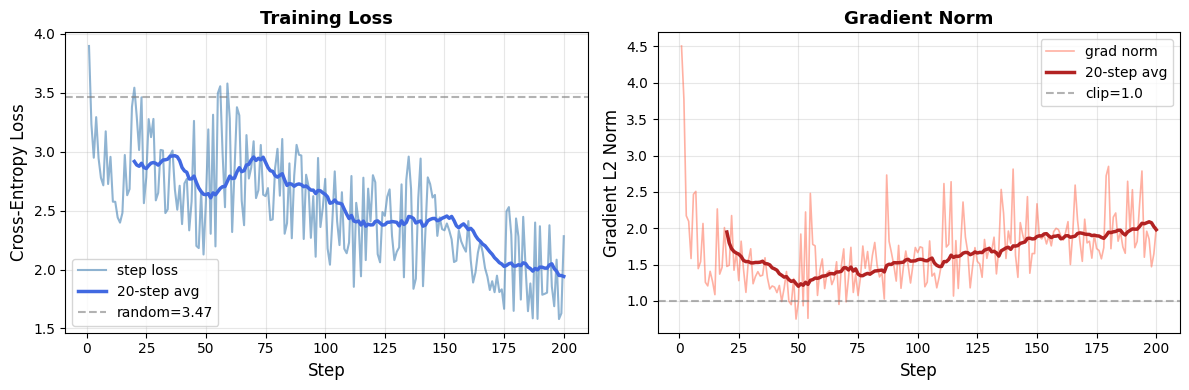

訓練曲線已儲存


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── 圖 1：Loss 曲線 ───────────────────────────────────────────────────────────
ax = axes[0]
steps = np.arange(1, N_STEPS + 1)
ax.plot(
    steps, loss_history, color="steelblue", linewidth=1.5, alpha=0.6, label="step loss"
)
# 平滑曲線（移動平均）
window = 20
smooth = np.convolve(loss_history, np.ones(window) / window, mode="valid")
ax.plot(
    steps[window - 1 :],
    smooth,
    color="royalblue",
    linewidth=2.5,
    label=f"{window}-step avg",
)
ax.axhline(
    math.log(V),
    color="gray",
    linestyle="--",
    alpha=0.6,
    label=f"random={math.log(V):.2f}",
)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Training Loss", fontsize=13, fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# ── 圖 2：梯度範數曲線 ────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(
    steps,
    grad_norm_history,
    color="tomato",
    linewidth=1.2,
    alpha=0.5,
    label="grad norm",
)
smooth_gn = np.convolve(grad_norm_history, np.ones(window) / window, mode="valid")
ax2.plot(
    steps[window - 1 :],
    smooth_gn,
    color="firebrick",
    linewidth=2.5,
    label=f"{window}-step avg",
)
ax2.axhline(CLIP, color="gray", linestyle="--", alpha=0.6, label=f"clip={CLIP}")
ax2.set_xlabel("Step", fontsize=12)
ax2.set_ylabel("Gradient L2 Norm", fontsize=12)
ax2.set_title("Gradient Norm", fontsize=13, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("訓練曲線已儲存")

## 12. 注意力權重視覺化

每個注意力頭學到不同的「關注模式」。可視化 Attention Map 幫助理解模型學了什麼。

/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/573852395.py:36: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/573852395.py:37: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  plt.savefig('/tmp/attention_maps.png', dpi=120, bbox_inches='tight')
/opt/anaconda3/envs/transformer/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65306 (\N{FULLWIDTH COLON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


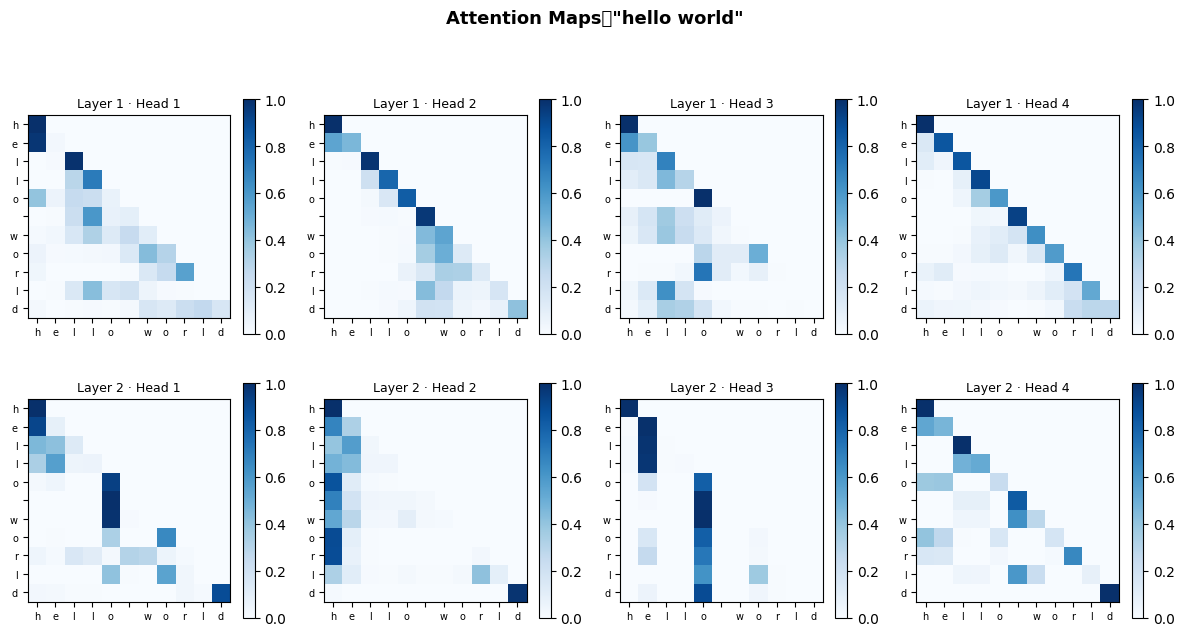

注意力圖：2 層 × 4 頭


In [27]:
def get_attention_maps(model, text):
    """前向傳播並收集所有層、所有頭的注意力矩陣"""
    ids = np.array([char2id.get(c, 0) for c in text])
    _ = model.forward(ids)  # 觸發 cache 更新

    attn_maps = []  # list of (n_heads, T, T) per layer
    for block in model.blocks:
        if block.attn._cache is not None:
            attn_maps.append(block.attn._cache[7])  # index 7 = attn weights
    return attn_maps, list(text)


probe_text = "hello world"
attn_maps, chars = get_attention_maps(model, probe_text)
T_probe = len(probe_text)

n_layers_show = len(attn_maps)
fig, axes = plt.subplots(
    n_layers_show, N_HEADS, figsize=(3 * N_HEADS, 3.2 * n_layers_show)
)
if n_layers_show == 1:
    axes = axes[np.newaxis, :]

for layer_idx, attn in enumerate(attn_maps):  # attn: (H, T, T)
    for head_idx in range(N_HEADS):
        ax = axes[layer_idx, head_idx]
        mat = attn[head_idx]  # (T, T)
        im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=mat.max())
        ax.set_xticks(range(T_probe))
        ax.set_yticks(range(T_probe))
        ax.set_xticklabels(chars, fontsize=7)
        ax.set_yticklabels(chars, fontsize=7)
        ax.set_title(f"Layer {layer_idx+1} · Head {head_idx+1}", fontsize=9)
        plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle(f'Attention Maps："{probe_text}"', fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/tmp/attention_maps.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"注意力圖：{n_layers_show} 層 × {N_HEADS} 頭")

## 13. 文字生成（Temperature + Top-k Sampling）

In [28]:
def generate(model, prompt, max_new=30, temperature=1.0, top_k=None):
    """
    自回歸文字生成，支援 Top-k Sampling。

    top_k: 只從機率最高的 k 個 token 中採樣；None = 全詞彙表
    temperature: < 1 更確定，> 1 更隨機
    """
    ids = [char2id.get(c, 0) for c in prompt]
    generated = list(prompt)

    for _ in range(max_new):
        ctx = np.array(ids[-SEQ_LEN:])  # 滑動視窗
        logits = model.forward(ctx)[-1]  # (V,) 最後位置
        logits = logits / temperature

        # Top-k Filtering（將非 top-k 的 logits 設為 -inf）
        if top_k is not None:
            threshold = np.sort(logits)[-top_k]
            logits = np.where(logits >= threshold, logits, -1e9)

        probs = softmax(logits)
        next_id = int(np.random.choice(V, p=probs))
        ids.append(next_id)
        generated.append(id2char[next_id])

    return "".join(generated)


np.random.seed(42)
print("=" * 55)
print("文字生成示範（200 步訓練後）")
print("=" * 55)

for prompt in ["the ", "hello ", "to be"]:
    print(f"\n  Prompt: '{prompt}'")
    for temp, topk, label in [
        (0.7, 5, "temp=0.7 top-k=5  （保守）"),
        (1.0, None, "temp=1.0 top-k=∞  （標準）"),
        (1.3, 10, "temp=1.3 top-k=10 （創意）"),
    ]:
        result = generate(model, prompt, max_new=25, temperature=temp, top_k=topk)
        print(f"    {label}: '{result}'")

文字生成示範（200 步訓練後）

  Prompt: 'the '
    temp=0.7 top-k=5  （保守）: 'the t ton be th thes t one ti'
    temp=1.0 top-k=∞  （標準）: 'the the besh uene ne awher qd'
    temp=1.3 top-k=10 （創意）: 'the t t quathex tifon b. datz'

  Prompt: 'hello '
    temp=0.7 top-k=5  （保守）: 'hello t be t one t t fon t tiat'
    temp=1.0 top-k=∞  （標準）: 'hello brr tiotiath t t.s ot. ca'
    temp=1.3 top-k=10 （創意）: 'hello n tattiat. otiu fieratogo'

  Prompt: 'to be'
    temp=0.7 top-k=5  （保守）: 'to be be the one ton. fat be t'
    temp=1.0 top-k=∞  （標準）: 'to bes h ber tis s fat. ior t '
    temp=1.3 top-k=10 （創意）: 'to be be odhsaqoven fisx swati'


## 14. 各層梯度流分析（梯度健康度檢查）

梯度消失/爆炸是訓練深層模型的常見問題。可視化每層的梯度 L2 norm 幫助診斷。

/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/764869956.py:53: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/764869956.py:53: UserWarning: Glyph 23652 (\N{CJK UNIFIED IDEOGRAPH-5C64}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/764869956.py:53: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/764869956.py:53: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90hjfpmfzcq9h0000gn/T/ipykernel_4035/764869956.py:53: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/p1/2yp706d10gq90h

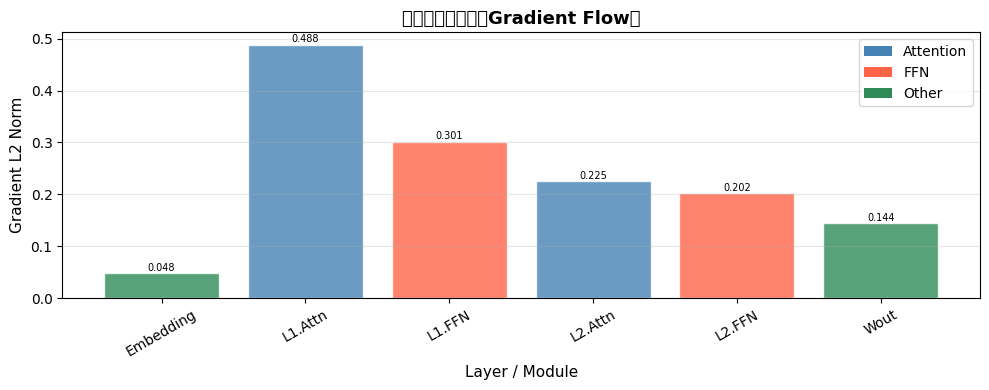

In [29]:
def analyze_grad_flow(model, text, targets_text):
    """
    執行一次前向+反向傳播，收集各層參數的梯度 norm。
    """
    ids = np.array([char2id.get(c, 0) for c in text])
    tgt = np.array([char2id.get(c, 0) for c in targets_text])
    logits = model.forward(ids)
    model.backward_and_update(logits, tgt, lr=0.0, t=1)  # lr=0 不更新

    grad_data = []
    # Embedding
    grad_data.append(("Embedding", float(np.linalg.norm(model._emb_adam.m))))
    # Blocks
    for li, block in enumerate(model.blocks):
        for name, grads in [("Attn", block.attn._grads), ("FFN", block.ff._grads)]:
            norm = math.sqrt(sum((g**2).sum() for g in grads.values()))
            grad_data.append((f"L{li+1}.{name}", norm))
    # Wout
    grad_data.append(("Wout", float(np.linalg.norm(model._wout_adam.m))))
    return grad_data


in_text = TRAIN_TEXT[:SEQ_LEN]
tgt_text = TRAIN_TEXT[1 : SEQ_LEN + 1]
grad_data = analyze_grad_flow(model, in_text, tgt_text)

labels = [d[0] for d in grad_data]
norms = [d[1] for d in grad_data]

fig, ax = plt.subplots(figsize=(10, 4))
colors = [
    "steelblue" if "Attn" in l else "tomato" if "FFN" in l else "seagreen"
    for l in labels
]
bars = ax.bar(labels, norms, color=colors, alpha=0.8, edgecolor="white")
ax.set_xlabel("Layer / Module", fontsize=11)
ax.set_ylabel("Gradient L2 Norm", fontsize=11)
ax.set_title("各層梯度流分析（Gradient Flow）", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=30)
ax.grid(axis="y", alpha=0.3)

# 圖例
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="steelblue", label="Attention"),
    Patch(facecolor="tomato", label="FFN"),
    Patch(facecolor="seagreen", label="Other"),
]
ax.legend(handles=legend_elements)

for bar, norm in zip(bars, norms):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f"{norm:.3f}",
        ha="center",
        va="bottom",
        fontsize=7,
    )

plt.tight_layout()
plt.savefig("/tmp/grad_flow.png", dpi=120, bbox_inches="tight")
plt.show()

## 15. 整合：架構與訓練流程總覽

In [30]:
print("=" * 60)
print("MiniLLM 模型摘要")
print("=" * 60)
print(f"  詞彙表大小:  {V}")
print(f"  d_model:     {D}")
print(f"  FFN 維度:    {D_FF}")
print(f"  注意力頭數:  {N_HEADS}  (每頭 dk={D//N_HEADS})")
print(f"  Layers:      {N_LAYERS}")
print(f"  最大序列長:  {SEQ_LEN}")

print("\n" + "=" * 60)
print("參數量明細")
print("=" * 60)

param_table = [
    ("Embedding", model.emb_W.shape, model.emb_W.size),
    ("Wout", model.Wout.shape, model.Wout.size),
]
for li, block in enumerate(model.blocks):
    for name, W in [
        ("Wq", block.attn.Wq),
        ("Wk", block.attn.Wk),
        ("Wv", block.attn.Wv),
        ("Wo", block.attn.Wo),
    ]:
        param_table.append((f"L{li+1}.Attn.{name}", W.shape, W.size))
    for name, W in [("W1", block.ff.W1), ("W2", block.ff.W2)]:
        param_table.append((f"L{li+1}.FFN.{name}", W.shape, W.size))

total = sum(p[2] for p in param_table)
for name, shape, size in param_table:
    print(f"  {name:<22s}  {str(shape):<15}  {size:>6,}")
print("-" * 60)
print(f"  {'總計':<22s}  {'':15}  {total:>6,}")

print("\n" + "=" * 60)
print("訓練摘要")
print("=" * 60)
print(f"  訓練步數:    {N_STEPS}")
print(f"  優化器:      Adam (lr={LR}, β1=0.9, β2=0.999)")
print(f"  梯度裁剪:    {CLIP}")
print(f"  初始 Loss:   {loss_history[0]:.4f}")
print(f"  最終 Loss:   {loss_history[-1]:.4f}")
print(
    f"  改善幅度:    {loss_history[0]-loss_history[-1]:.4f} ({(1-loss_history[-1]/loss_history[0])*100:.1f}% ↓)"
)
print(f"  理論隨機Loss: {math.log(V):.4f}")

MiniLLM 模型摘要
  詞彙表大小:  32
  d_model:     64
  FFN 維度:    128
  注意力頭數:  4  (每頭 dk=16)
  Layers:      2
  最大序列長:  32

參數量明細
  Embedding               (32, 64)          2,048
  Wout                    (64, 32)          2,048
  L1.Attn.Wq              (64, 64)          4,096
  L1.Attn.Wk              (64, 64)          4,096
  L1.Attn.Wv              (64, 64)          4,096
  L1.Attn.Wo              (64, 64)          4,096
  L1.FFN.W1               (64, 128)         8,192
  L1.FFN.W2               (128, 64)         8,192
  L2.Attn.Wq              (64, 64)          4,096
  L2.Attn.Wk              (64, 64)          4,096
  L2.Attn.Wv              (64, 64)          4,096
  L2.Attn.Wo              (64, 64)          4,096
  L2.FFN.W1               (64, 128)         8,192
  L2.FFN.W2               (128, 64)         8,192
------------------------------------------------------------
  總計                                       69,632

訓練摘要
  訓練步數:    200
  優化器:      Adam (lr=0.003, β1=0.9, β2=0.999)


## 延伸學習

| 功能 | 數值微分版 | **本版（完整 Backprop）** | 生產級 LLM |
|---|---|---|---|
| 梯度計算 | 數值微分 O(P) | ✅ 解析反向傳播 O(1) | Autograd + CUDA |
| 優化器 | SGD | ✅ Adam | AdamW + LR schedule |
| 注意力 | 單頭 | ✅ 多頭 MHA | GQA / MQA / Flash Attn |
| 梯度穩定 | 無 | ✅ Gradient Clipping | Grad clip + LR warmup |
| 可監控性 | 損失數字 | ✅ 曲線 + Attn map + 梯度流 | W&B / TensorBoard |
| LN 架構 | Post-LN | ✅ Pre-LN | Pre-LN + RMSNorm |
| 採樣策略 | 基本 | ✅ Temperature + Top-k | + Top-p (Nucleus) |

**本版實作的核心反向傳播技術：**
- `softmax + CE` 聯合梯度：`(probs - onehot) / T`
- `LayerNorm` 梯度：三項化簡（移除均值分量與 scale 分量）
- `Attention softmax` Jacobian：`attn * (d_attn - sum(attn*d_attn))`
- `Embedding` 梯度：`np.add.at` scatter-add（同 token 梯度累加）
- `殘差連接` 梯度：直通（dout 直接加到 dX）

**推薦下一步：**
- 🔗 [Andrej Karpathy - micrograd](https://github.com/karpathy/micrograd)（自動微分引擎，50 行）
- 🔗 [Andrej Karpathy - nanoGPT](https://github.com/karpathy/nanoGPT)（真正的 GPT，PyTorch）
- 📖 [The Matrix Calculus You Need For Deep Learning](https://explained.ai/matrix-calculus/)（矩陣微積分教材）
- 🛠️ 嘗試用 JAX 的 `jax.grad` 對比本版手推梯度